In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# df = pd.read_csv("Advertising.csv", index_col=False) used to force pandas to not use the first column as the index
df = pd.read_csv("Advertising.csv")

In [3]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df.drop(df.columns[0], axis=1, inplace=True)
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [5]:
X = df.drop(columns=["sales"], axis=1)
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [6]:
y = df["sales"]
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transfomer = StandardScaler()

preprocessor = ColumnTransformer ([
    ("StandardScalar", numerical_transfomer, X.columns)
])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

In [9]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [10]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted)
    r2_squared = r2_score(actual, predicted)
    return mae, rmse, r2_squared

In [11]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mae, train_mse, train_r2 = evaluate_model(Y_train, y_train_pred)
test_mae, test_mse, test_r2 = evaluate_model(Y_test, y_test_pred)

print("Linear Regression")
print(f"Training: mae: {train_mae} rmse: {train_mse} r2: {train_r2}")
print(f"Testing: mae: {test_mae} rmse: {test_mse} r2: {test_r2}")

Linear Regression
Training: mae: 1.1984678961500133 rmse: 2.7051294230814142 r2: 0.8957008271017817
Testing: mae: 1.4607567168117601 rmse: 3.1740973539761073 r2: 0.8994380241009119


In [13]:
score = r2_score(Y_test, y_test_pred)*100
print(f"Accuarcy r2 score: {score}")

Accuarcy r2 score: 89.9438024100912


Text(0, 0.5, 'Predicted')

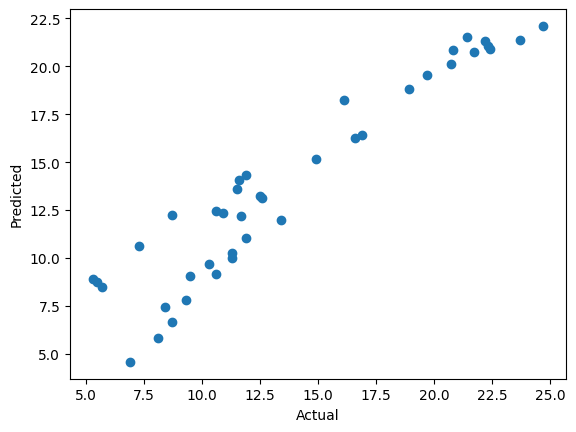

In [14]:
plt.scatter(Y_test, y_test_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

<Axes: xlabel='sales'>

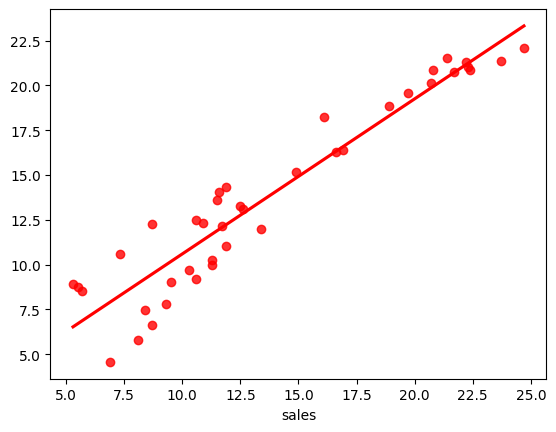

In [15]:
sns.regplot(x=Y_test, y=y_test_pred, ci=None, color="red")

In [16]:
pred_df = pd.DataFrame({"Actual":Y_test, "Predicted":y_test_pred, "Diffrence":Y_test-y_test_pred})
pred_df.to_csv("actual_vs_predicted.csv", index=False)
pred_df

,Actual,Predicted,Diffrence
95,16.9,16.408024,0.491976
15,22.4,20.889882,1.510118
30,21.4,21.553843,-0.153843
158,7.3,10.608503,-3.308503
128,24.7,22.112373,2.587627
115,12.6,13.105592,-0.505592
69,22.3,21.057192,1.242808
170,8.4,7.461010,0.938990
174,11.5,13.606346,-2.106346
45,14.9,15.155070,-0.255070


In [17]:
import joblib
joblib.dump(model, "model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [18]:
new_advertise = pd.DataFrame({
    "TV": [199.8],
    "radio": [2.6],
    "newspaper": [21.2],
    "sales": [10.6]
})

In [19]:
X_new = new_advertise.drop(columns=["sales"])
new_advertise_processed = preprocessor.transform(X_new)

In [20]:
predicted_sales = model.predict(new_advertise_processed)[0]
predicted_sales

12.466467693418515

In [21]:
actual_sales = new_advertise["sales"].values[0]
difference = actual_sales - predicted_sales

new_advertise_result = pd.DataFrame({
    "Actual Sales": [actual_sales],
    "Predicted Sales": [predicted_sales],
    "Difference": [difference]
})

new_advertise_result

,Actual Sales,Predicted Sales,Difference
0,10.6,12.466468,-1.866468
